# FEA Surrogate Model: Exploratory Analysis & Baselines

This notebook provides an interactive walkthrough of the Finite Element Analysis (FEA) surrogate modeling project for a **plate with a central circular hole under uniaxial tension**.

### Objectives
1. **Understand the Physics & FEA**: Inspect the quarter-plate symmetry model, boundary conditions, and full 2D Von Mises stress fields.
2. **Explore the Dataset**: Inspect the 1,000 simulations generated via Latin Hypercube Sampling (LHS).
3. **Verify FEA Against Analytical Theory**: Validate FEA peak stress against Peterson's stress concentration formula.
4. **Train & Evaluate Surrogate Baselines**: Compare Linear Regression, Polynomial (Degree 3) + Ridge, Gradient Boosting, Gaussian Process (ARD), and MLP.
5. **Diagnose Error & Extrapolation**: Evaluate model failure modes outside the training range ($d/W \ge 0.45$) and analyze physics learned by the models (scale invariance via GP length scales).


In [1]:
# Setup environment & imports
import sys
import os
import time

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# FEA tools
import gmsh
from skfem import Basis, ElementVector, ElementTriP2, ElementTriP1, FacetBasis, LinearForm, asm, condense, solve
from skfem.models.elasticity import lame_parameters, linear_elasticity

# ML tools
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from data_gen.gen_data import make_mesh, peak_stress_theory, E, NU, RANGES

# Plotting style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
print("Environment and packages loaded successfully.")


Environment and packages loaded successfully.


## 1. Physics & FEA Simulation (Full Field Visualization)

### Boundary Value Problem
We model a quarter of a rectangular plate of width $W$, height $H$, with a central circular hole of radius $r = (d/W) \cdot W / 2$:
* **Left edge ($x = 0$):** Symmetry plane $\rightarrow u_x = 0$.
* **Bottom edge ($y = 0$):** Symmetry plane $\rightarrow u_y = 0$.
* **Top edge ($y = H/2$):** Uniform tensile traction $\sigma$ in $+y$.
* **Hole arc & Right edge:** Traction-free.
* **Governing equations:** Linear elasticity, plane stress, isotropic material ($E = 210\text{ GPa}, \nu = 0.30$).
* **Elements:** Quadratic triangular elements (`ElementTriP2`) with $L_2$ projection onto linear elements (`ElementTriP1`) for smooth nodal Von Mises stress.


In [2]:
def solve_plate_full_field(W, H, r, sigma, n_hole=16):
    """
    Solves linear elasticity on the quarter plate and returns the mesh along with
    the complete nodal Von Mises stress field.
    
    Parameters:
        W (float): Plate width [mm]
        H (float): Plate height [mm]
        r (float): Hole radius [mm]
        sigma (float): Applied gross tensile stress [MPa]
        n_hole (int): Element resolution along the hole arc
        
    Returns:
        mesh (skfem.MeshTri): Finite element mesh
        vm_nodal (np.ndarray): Nodal Von Mises stress values [MPa]
        info (dict): Peak stress, mesh stats, and solve timings
    """
    t0 = time.perf_counter()
    mesh = make_mesh(W, H, r, n_hole=n_hole)
    t_mesh = time.perf_counter() - t0

    t1 = time.perf_counter()
    basis = Basis(mesh, ElementVector(ElementTriP2()))

    lam, mu = lame_parameters(E, NU)
    lam = 2 * lam * mu / (lam + 2 * mu)  # Plane stress correction
    K = asm(linear_elasticity(lam, mu), basis)

    fb = FacetBasis(mesh, basis.elem, facets=mesh.boundaries["top"])

    @LinearForm
    def traction(v, w):
        return sigma * v.value[1]

    f = asm(traction, fb)

    def comp_dofs(facets, comp):
        d = basis.get_dofs(facets)
        return np.concatenate([d.nodal[comp], d.facet[comp]])

    # Symmetry Dirichlet boundary conditions
    D = np.concatenate([
        comp_dofs(mesh.boundaries["left"], "u^1"),    # u_x = 0 on x = 0
        comp_dofs(mesh.boundaries["bottom"], "u^2"),  # u_y = 0 on y = 0
    ])
    u = solve(*condense(K, f, D=D))

    # Calculate stresses at quadrature points
    g = basis.interpolate(u).grad  # du_i/dx_j
    exx, eyy = g[0, 0], g[1, 1]
    exy = 0.5 * (g[0, 1] + g[1, 0])
    c = E / (1 - NU ** 2)
    sxx = c * (exx + NU * eyy)
    syy = c * (eyy + NU * exx)
    sxy = E / (1 + NU) * exy
    vm = np.sqrt(sxx ** 2 - sxx * syy + syy ** 2 + 3 * sxy ** 2)

    # L2 nodal projection onto linear triangles
    p1 = Basis(mesh, ElementTriP1(), quadrature=basis.quadrature)
    vm_nodal = p1.project(vm)
    t_solve = time.perf_counter() - t1

    info = {
        "peak_vm": float(vm_nodal.max()),
        "n_nodes": int(mesh.p.shape[1]),
        "n_elems": int(mesh.t.shape[1]),
        "t_mesh": t_mesh,
        "t_solve": t_solve,
        "kt_gross": float(vm_nodal.max()) / sigma
    }
    return mesh, vm_nodal, info


def plot_mesh_and_stress_field(mesh, vm_nodal, W, H, r, sigma):
    """
    Plots side-by-side visualizations of the finite element mesh and the
    resulting Von Mises stress contour field.
    """
    triang = mtri.Triangulation(mesh.p[0], mesh.p[1], mesh.t.T)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # 1. Mesh Plot
    ax1.triplot(triang, color="darkslategray", lw=0.4, alpha=0.7)
    ax1.plot([0, 0], [r, H / 2], "b-", lw=2, label="Left: u_x = 0 (symm)")
    ax1.plot([r, W / 2], [0, 0], "g-", lw=2, label="Bottom: u_y = 0 (symm)")
    ax1.plot([0, W / 2], [H / 2, H / 2], "r-", lw=2, label=f"Top: traction $\\sigma$ = {sigma:.0f} MPa")
    ax1.set_aspect("equal")
    ax1.set_title(f"Quarter Mesh ({mesh.t.shape[1]} elements, refined near hole)")
    ax1.set_xlabel("x [mm]")
    ax1.set_ylabel("y [mm]")
    ax1.legend(loc="upper right", fontsize=8)

    # 2. Stress Field Plot
    levels = np.linspace(vm_nodal.min(), vm_nodal.max(), 30)
    cnt = ax2.tricontourf(triang, vm_nodal, levels=levels, cmap="inferno")
    cbar = fig.colorbar(cnt, ax=ax2, pad=0.02)
    cbar.set_label("Von Mises Stress $\\sigma_{vm}$ [MPa]")

    # Highlight peak stress location at (r, 0)
    peak_idx = np.argmax(vm_nodal)
    px, py = mesh.p[0, peak_idx], mesh.p[1, peak_idx]
    ax2.plot(px, py, "c*", markersize=14, markeredgecolor="black", label=f"Peak: {vm_nodal.max():.1f} MPa at ({px:.1f}, {py:.1f})")

    ax2.set_aspect("equal")
    ax2.set_title(f"Von Mises Stress Field ($K_t = {vm_nodal.max() / sigma:.2f}$)")
    ax2.set_xlabel("x [mm]")
    ax2.set_ylabel("y [mm]")
    ax2.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()


Solving quarter plate FEA: W=100.0 mm, H=250.0 mm, d/W=0.2, sigma=100.0 MPa...


FEA Peak Stress: 314.14 MPa  |  Theory: 313.52 MPa  |  Diff: +0.20%
Total FEA runtime: 0.257 s (1150 elements)


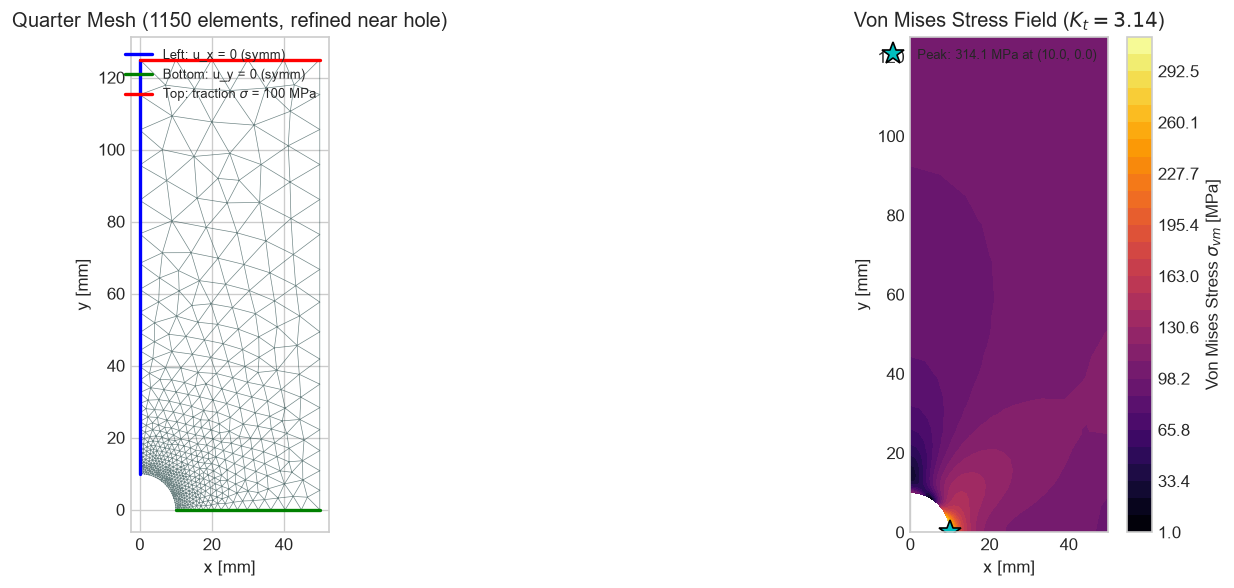

In [3]:
# Run a single FEA simulation and display the stress field
sample_W = 100.0
sample_H = 250.0
sample_d_over_W = 0.20
sample_r = sample_d_over_W * sample_W / 2  # 10 mm
sample_sigma = 100.0  # MPa

print(f"Solving quarter plate FEA: W={sample_W} mm, H={sample_H} mm, d/W={sample_d_over_W}, sigma={sample_sigma} MPa...")
mesh, vm_nodal, info = solve_plate_full_field(sample_W, sample_H, sample_r, sample_sigma, n_hole=24)
th_peak = peak_stress_theory(sample_sigma, sample_d_over_W)

print(f"FEA Peak Stress: {info['peak_vm']:.2f} MPa  |  Theory: {th_peak:.2f} MPa  |  Diff: {100*(info['peak_vm']-th_peak)/th_peak:+.2f}%")
print(f"Total FEA runtime: {info['t_mesh'] + info['t_solve']:.3f} s ({info['n_elems']} elements)")

plot_mesh_and_stress_field(mesh, vm_nodal, sample_W, sample_H, sample_r, sample_sigma)


## 2. Dataset Exploration (Latin Hypercube Sampling)

The dataset in `data/plate_hole.csv` contains 1,000 simulations sampled via Latin Hypercube Sampling (LHS, random seed 42) across the bounded ranges:
* $W \in [60, 200]$ mm
* $d/W \in [0.05, 0.50]$
* $H/W \in [2.0, 3.0]$
* $\sigma \in [50, 200]$ MPa

The target is **$K_t = \sigma_{\text{peak}} / \sigma$**.


Loaded 1000/1000 successful simulation runs.


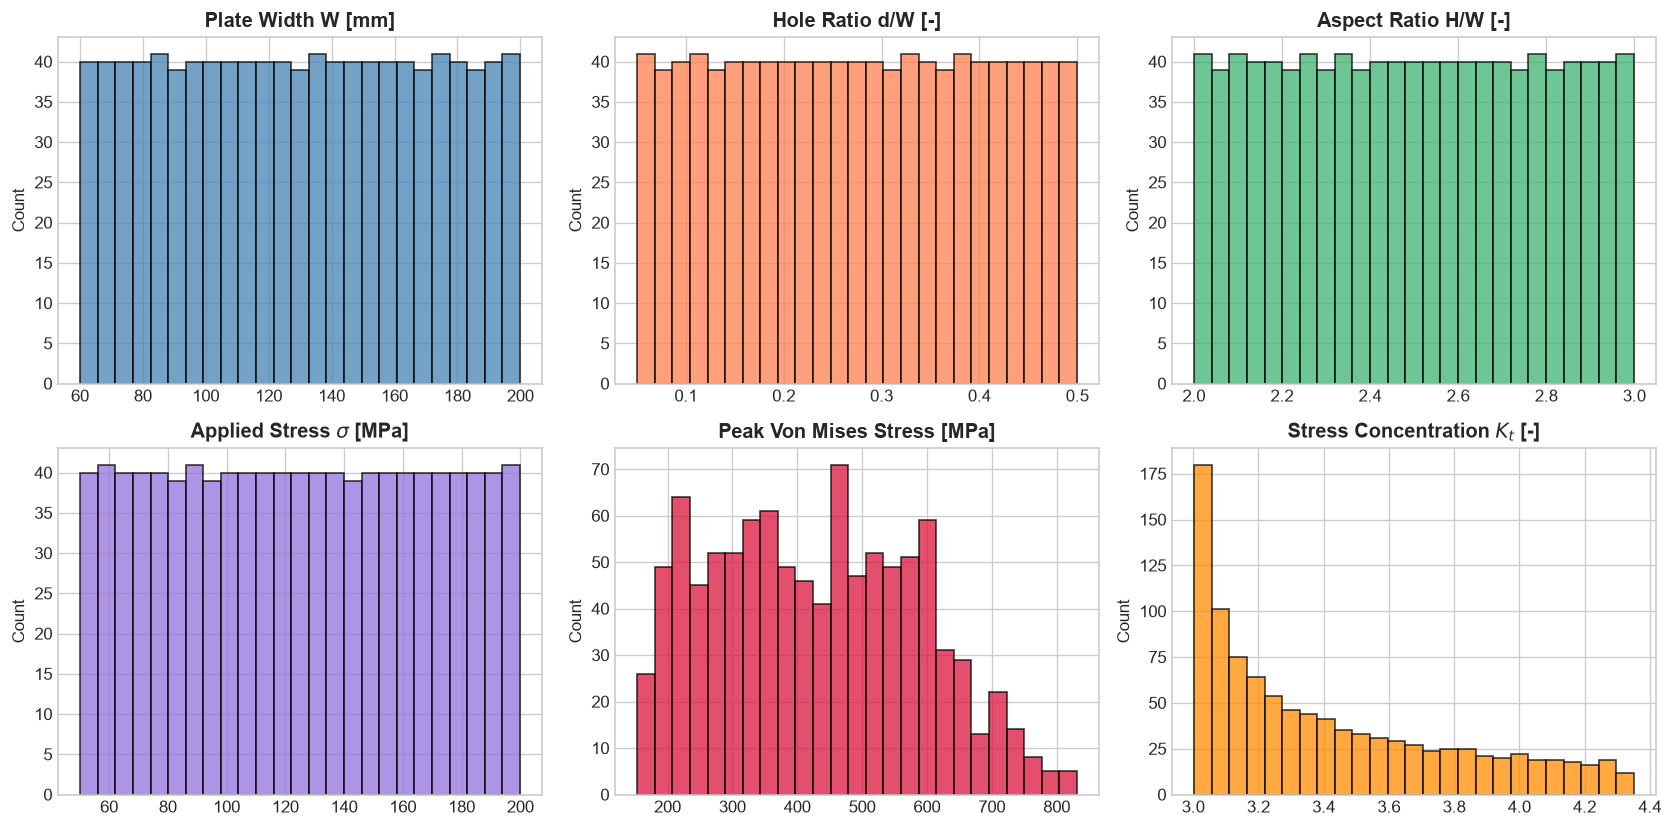

In [4]:
def load_and_inspect_dataset(csv_path="../data/plate_hole.csv"):
    """Loads and validates the simulation dataset."""
    df = pd.read_csv(csv_path)
    df_clean = df[df["ok"].astype(str) == "True"].copy().reset_index(drop=True)
    print(f"Loaded {len(df_clean)}/{len(df)} successful simulation runs.")
    return df_clean


def plot_parameter_distributions(df):
    """Plots histograms showing parameter distributions from Latin Hypercube Sampling."""
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten()

    vars_to_plot = [
        ("W", "Plate Width W [mm]", "steelblue"),
        ("d_over_W", "Hole Ratio d/W [-]", "coral"),
        ("H_over_W", "Aspect Ratio H/W [-]", "mediumseagreen"),
        ("sigma", "Applied Stress $\\sigma$ [MPa]", "mediumpurple"),
        ("peak_vm", "Peak Von Mises Stress [MPa]", "crimson"),
        ("kt_gross", "Stress Concentration $K_t$ [-]", "darkorange"),
    ]

    for ax, (col, title, color) in zip(axes, vars_to_plot):
        ax.hist(df[col], bins=25, color=color, edgecolor="black", alpha=0.75)
        ax.set_title(title, fontweight="bold")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()


df = load_and_inspect_dataset()
plot_parameter_distributions(df)


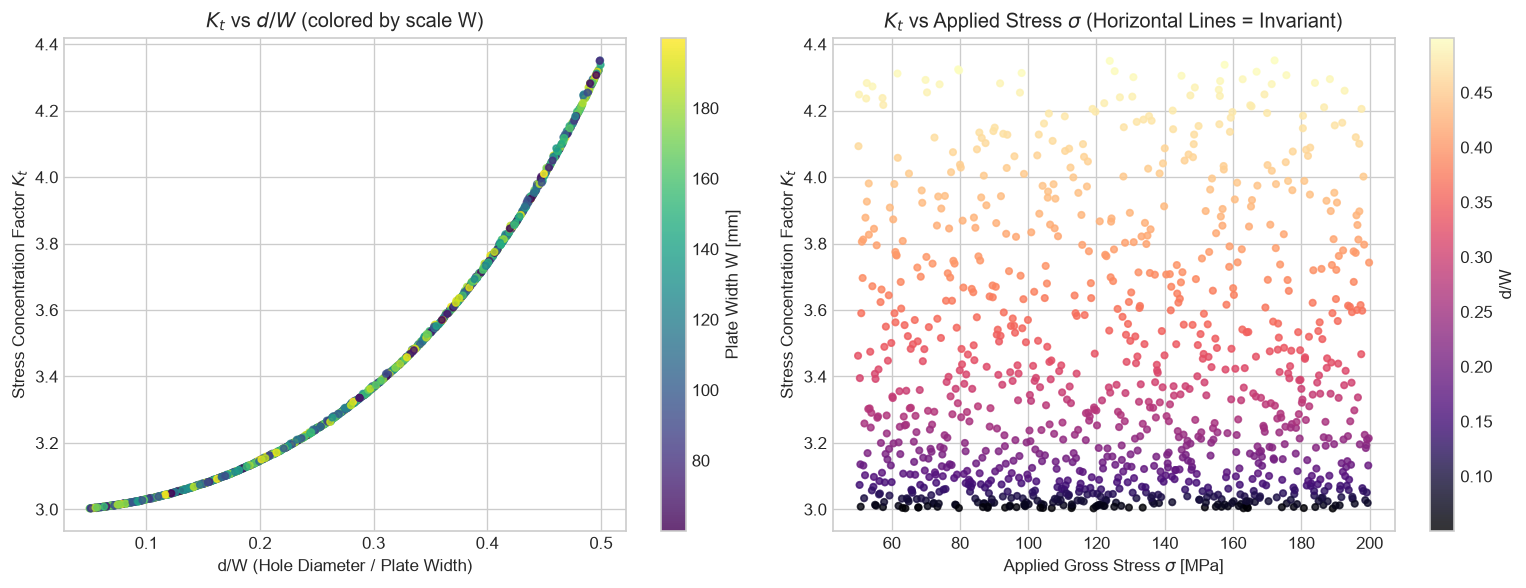

In [5]:
def plot_physics_dependencies(df):
    """
    Demonstrates that Kt depends purely on dimensionless geometry (d/W),
    and is invariant to scale (W) and load (sigma).
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # 1. Kt vs d/W colored by plate width W
    sc1 = ax1.scatter(df["d_over_W"], df["kt_gross"], c=df["W"], cmap="viridis", s=15, alpha=0.8)
    cb1 = fig.colorbar(sc1, ax=ax1)
    cb1.set_label("Plate Width W [mm]")
    ax1.set_xlabel("d/W (Hole Diameter / Plate Width)")
    ax1.set_ylabel("Stress Concentration Factor $K_t$")
    ax1.set_title("$K_t$ vs $d/W$ (colored by scale W)")

    # 2. Kt vs Applied Stress sigma colored by d/W
    sc2 = ax2.scatter(df["sigma"], df["kt_gross"], c=df["d_over_W"], cmap="magma", s=15, alpha=0.8)
    cb2 = fig.colorbar(sc2, ax=ax2)
    cb2.set_label("d/W")
    ax2.set_xlabel("Applied Gross Stress $\\sigma$ [MPa]")
    ax2.set_ylabel("Stress Concentration Factor $K_t$")
    ax2.set_title("$K_t$ vs Applied Stress $\\sigma$ (Horizontal Lines = Invariant)")

    plt.tight_layout()
    plt.show()

plot_physics_dependencies(df)


## 3. FEA Verification Against Peterson's Analytical Formula

Peterson's formula for a finite-width plate with a central hole in tension is defined based on net-section stress $\sigma_{\text{net}} = \sigma / (1 - d/W)$:
$$K_{t,\text{net}} = 3.00 - 3.13(d/W) + 3.66(d/W)^2 - 1.53(d/W)^3$$
$$\sigma_{\text{peak, theory}} = K_{t,\text{net}} \cdot \sigma_{\text{net}} = \frac{K_{t,\text{net}}}{1 - d/W} \sigma$$

We compare FEA $K_t$ against Peterson's theoretical value across the 1,000 simulations.


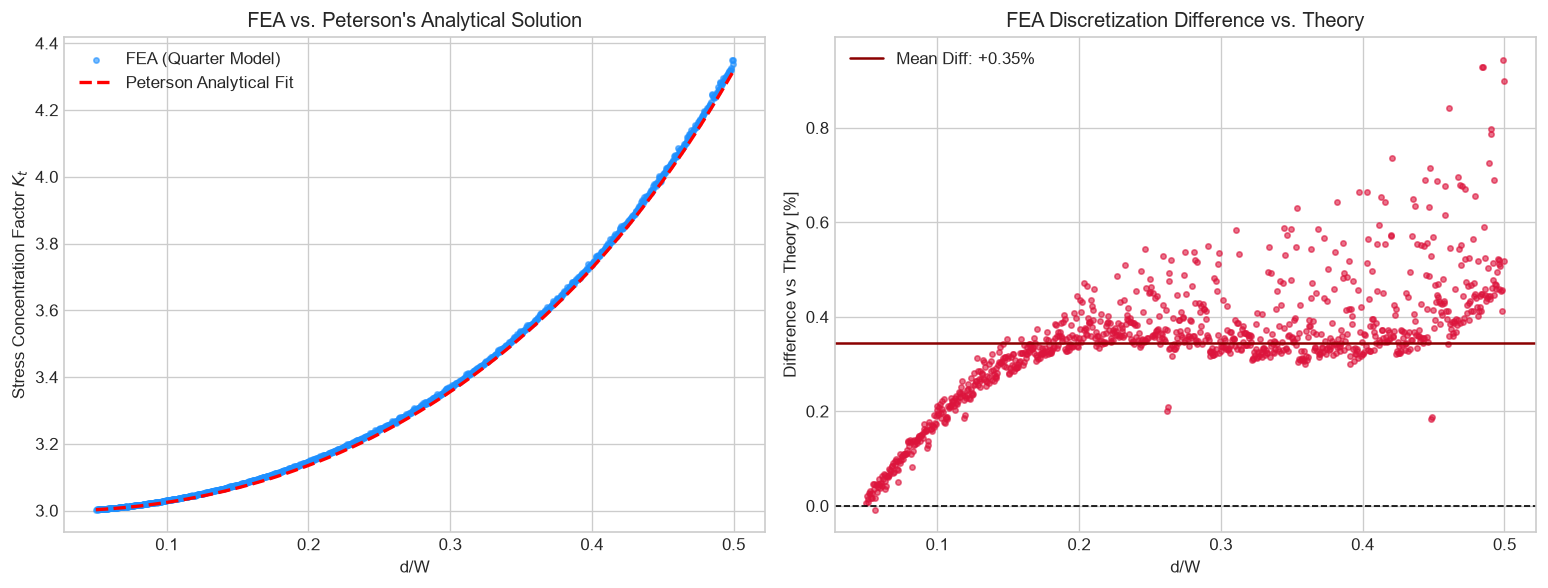

FEA vs Theory Difference: Mean = +0.345%, Min = -0.008%, Max = +0.945%
Notice: Difference stays within ~0.6%, consistent with mesh convergence.


In [6]:
def plot_fea_vs_theory(df):
    """
    Compares the FEA stress concentration against Peterson's analytical formula.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Sort by d/W for smooth analytical line
    d_sorted = np.linspace(0.05, 0.50, 200)
    th_curve = [peak_stress_theory(1.0, d) for d in d_sorted]

    # Panel 1: Curve comparison
    ax1.scatter(df["d_over_W"], df["kt_gross"], s=10, color="dodgerblue", alpha=0.6, label="FEA (Quarter Model)")
    ax1.plot(d_sorted, th_curve, "r--", lw=2, label="Peterson Analytical Fit")
    ax1.set_xlabel("d/W")
    ax1.set_ylabel("Stress Concentration Factor $K_t$")
    ax1.set_title("FEA vs. Peterson's Analytical Solution")
    ax1.legend()

    # Panel 2: Percentage difference
    diff_pct = 100 * (df["peak_vm"] - df["peak_theory"]) / df["peak_theory"]
    ax2.scatter(df["d_over_W"], diff_pct, s=10, color="crimson", alpha=0.6)
    ax2.axhline(0, color="black", lw=1, ls="--")
    ax2.axhline(diff_pct.mean(), color="darkred", lw=1.5, label=f"Mean Diff: {diff_pct.mean():+.2f}%")
    ax2.set_xlabel("d/W")
    ax2.set_ylabel("Difference vs Theory [%]")
    ax2.set_title("FEA Discretization Difference vs. Theory")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"FEA vs Theory Difference: Mean = {diff_pct.mean():+.3f}%, Min = {diff_pct.min():+.3f}%, Max = {diff_pct.max():+.3f}%")
    print("Notice: Difference stays within ~0.6%, consistent with mesh convergence.")

plot_fea_vs_theory(df)


## 4. Surrogate Models: Training & Evaluation

We evaluate five surrogate models using the exact split logic from `models/baselines.py`:
1. **Linear Regression:** Baseline to determine if ML is even needed.
2. **Poly3 + Ridge:** Degree 3 polynomial with $L_2$ regularization.
3. **Gradient Boosting:** Tree-based ensemble (`n_estimators=300`, `max_depth=3`).
4. **Gaussian Process (ARD):** RBF kernel with per-input length scales (`WhiteKernel` noise term).
5. **MLP:** Neural network (2 hidden layers of 64 units, tanh activation, L-BFGS solver).

### Two Evaluation Protocols:
* **Interpolation:** Random 70% train / 15% val / 15% test split (geometry-level split, seed 42).
* **Extrapolation:** Train on $d/W < 0.40$, test on $d/W \ge 0.45$ (stressing behavior outside the training domain).


In [7]:
FEATS = ["W", "d_over_W", "H_over_W"]
TARGET = "kt_gross"


def make_models(seed=42, n_feats=3):
    """Instantiates the 5 surrogate regression pipelines."""
    return {
        "Linear": make_pipeline(StandardScaler(), LinearRegression()),
        "Poly3+Ridge": make_pipeline(StandardScaler(), PolynomialFeatures(3), Ridge(alpha=1e-3)),
        "GradBoost": GradientBoostingRegressor(
            n_estimators=300, max_depth=3, learning_rate=0.05, random_state=seed
        ),
        "GP (ARD)": make_pipeline(
            StandardScaler(),
            GaussianProcessRegressor(
                kernel=C(1.0) * RBF([1.0] * n_feats) + WhiteKernel(1e-5, (1e-10, 1e-1)),
                normalize_y=True, n_restarts_optimizer=2, random_state=seed
            )
        ),
        "MLP": TransformedTargetRegressor(
            regressor=make_pipeline(
                StandardScaler(),
                MLPRegressor(hidden_layer_sizes=(64, 64), activation="tanh", solver="lbfgs",
                             max_iter=3000, random_state=seed)
            ),
            transformer=StandardScaler()
        ),
    }


def compute_metrics(y_true, y_pred):
    """Calculates MAE, relative errors, and R2."""
    rel = 100 * np.abs(y_pred - y_true) / y_true
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "mean_rel_err_%": rel.mean(),
        "max_rel_err_%": rel.max(),
        "R2": r2_score(y_true, y_pred),
    }


def fit_and_time(model, X_train, y_train, X_test):
    """Fits model, records training time and per-sample latency."""
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    pred = model.predict(X_test)
    pred_us = 1e6 * (time.perf_counter() - t1) / len(X_test)
    return pred, fit_time, pred_us


def run_surrogate_evaluation(df, seed=42):
    """
    Executes both interpolation and extrapolation evaluations across all models.
    """
    X = df[FEATS].values
    y = df[TARGET].values

    # A) Interpolation Split (70/15/15)
    Xtr, Xtmp, ytr, ytmp = train_test_split(X, y, test_size=0.30, random_state=seed)
    Xva, Xte, yva, yte = train_test_split(Xtmp, ytmp, test_size=0.50, random_state=seed)

    rows = []
    preds_interp = {}
    models_interp = make_models(seed=seed, n_feats=len(FEATS))

    for name, m in models_interp.items():
        pte, fit_s, pred_us = fit_and_time(m, Xtr, ytr, Xte)
        pva = m.predict(Xva)
        preds_interp[name] = pte
        m_val = compute_metrics(yva, pva)
        m_te = compute_metrics(yte, pte)
        rows.append({
            "split": "interp",
            "model": name,
            "val_mean_rel_%": m_val["mean_rel_err_%"],
            "test_mean_rel_%": m_te["mean_rel_err_%"],
            "test_max_rel_%": m_te["max_rel_err_%"],
            "MAE": m_te["MAE"],
            "R2": m_te["R2"],
            "fit_s": fit_s,
            "predict_us": pred_us
        })

    # B) Extrapolation Split (train d/W < 0.40, test d/W >= 0.45)
    tr = df[df["d_over_W"] < 0.40]
    te_ = df[df["d_over_W"] >= 0.45]

    preds_extrap = {}
    models_extrap = make_models(seed=seed, n_feats=len(FEATS))

    for name, m in models_extrap.items():
        p, fit_s, pred_us = fit_and_time(m, tr[FEATS].values, tr[TARGET].values, te_[FEATS].values)
        preds_extrap[name] = p
        m_ex = compute_metrics(te_[TARGET].values, p)
        rows.append({
            "split": "extrap",
            "model": name,
            "val_mean_rel_%": np.nan,
            "test_mean_rel_%": m_ex["mean_rel_err_%"],
            "test_max_rel_%": m_ex["max_rel_err_%"],
            "MAE": m_ex["MAE"],
            "R2": m_ex["R2"],
            "fit_s": fit_s,
            "predict_us": pred_us
        })

    res_df = pd.DataFrame(rows)
    return res_df, preds_interp, yte, preds_extrap, te_, models_interp

res_df, preds_interp, yte, preds_extrap, te_, trained_models = run_surrogate_evaluation(df)


C:\AA Final Prep\Projects\Surrogate Model\surrogate_fea\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\AA Final Prep\Projects\Surrogate Model\surrogate_fea\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [8]:
# Display formatted benchmark tables
print("=== Interpolation Results (70/15/15 random split) ===")
interp_table = res_df[res_df["split"] == "interp"].drop(columns=["split"])
display(interp_table.style.format({
    "val_mean_rel_%": "{:.3f}%",
    "test_mean_rel_%": "{:.3f}%",
    "test_max_rel_%": "{:.3f}%",
    "MAE": "{:.4f}",
    "R2": "{:.5f}",
    "fit_s": "{:.3f} s",
    "predict_us": "{:.1f} us"
}))

print("\n=== Extrapolation Results (train d/W < 0.40, test d/W >= 0.45) ===")
extrap_table = res_df[res_df["split"] == "extrap"].drop(columns=["split", "val_mean_rel_%"])
display(extrap_table.style.format({
    "test_mean_rel_%": "{:.2f}%",
    "test_max_rel_%": "{:.2f}%",
    "MAE": "{:.4f}",
    "R2": "{:.4f}",
    "fit_s": "{:.3f} s",
    "predict_us": "{:.1f} us"
}))


=== Interpolation Results (70/15/15 random split) ===


,model,val_mean_rel_%,test_mean_rel_%,test_max_rel_%,MAE,R2,fit_s,predict_us
0,Linear,2.751%,2.611%,6.818%,0.0920,0.92365,0.004 s,5.2 us
1,Poly3+Ridge,0.057%,0.064%,0.215%,0.0022,0.99996,0.005 s,7.8 us
2,GradBoost,0.055%,0.058%,0.270%,0.0021,0.99994,0.668 s,17.5 us
3,GP (ARD),0.012%,0.015%,0.182%,0.0005,0.99999,16.510 s,24.8 us
4,MLP,0.045%,0.048%,0.327%,0.0017,0.99996,5.143 s,18.3 us



=== Extrapolation Results (train d/W < 0.40, test d/W >= 0.45) ===


,model,test_mean_rel_%,test_max_rel_%,MAE,R2,fit_s,predict_us
5,Linear,9.80%,12.55%,0.4099,-17.3017,0.004 s,5.5 us
6,Poly3+Ridge,0.66%,1.17%,0.0278,0.9088,0.004 s,10.8 us
7,GradBoost,10.28%,14.06%,0.4304,-19.6252,0.630 s,16.7 us
8,GP (ARD),0.30%,0.58%,0.0128,0.9796,15.443 s,26.4 us
9,MLP,3.48%,6.35%,0.1461,-1.5830,2.145 s,30.6 us


## 5. Error Diagnostics & Physics Interpretation

### Parity Plots (Predicted vs. True)
A well-fit surrogate clusters tightly along the $y = x$ dashed diagonal.


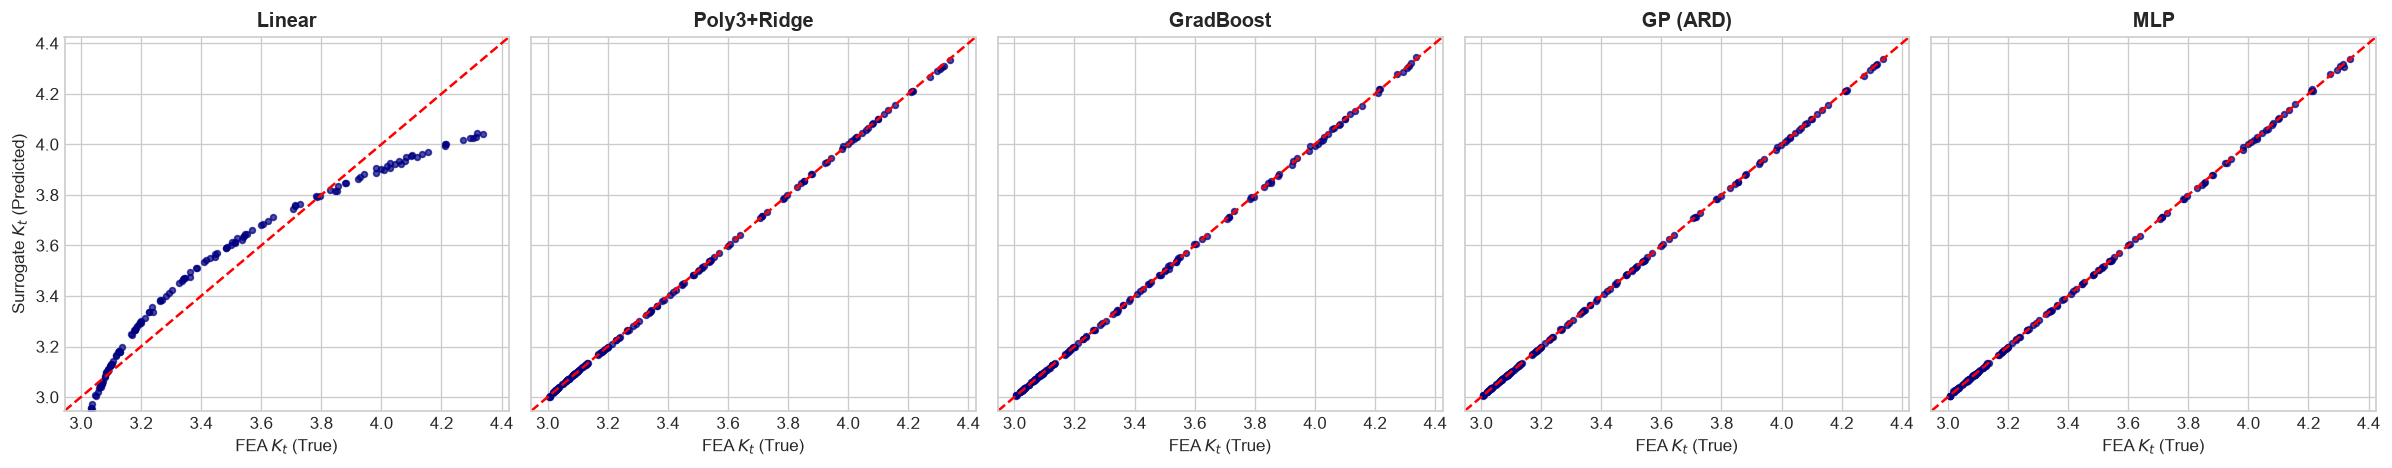

In [9]:
def plot_parity_scatter(yte, preds_interp):
    """Plots predicted vs true Kt on the interpolation test set."""
    fig, axes = plt.subplots(1, len(preds_interp), figsize=(4 * len(preds_interp), 4), sharex=True, sharey=True)
    lo, hi = yte.min() * 0.98, yte.max() * 1.02

    for ax, (name, p) in zip(axes, preds_interp.items()):
        ax.scatter(yte, p, s=12, alpha=0.7, color="navy")
        ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Ideal (y=x)")
        ax.set_title(name, fontweight="bold")
        ax.set_xlabel("FEA $K_t$ (True)")
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

    axes[0].set_ylabel("Surrogate $K_t$ (Predicted)")
    plt.tight_layout()
    plt.show()

plot_parity_scatter(yte, preds_interp)


### Extrapolation Failure Modes
When testing outside the training domain ($d/W \ge 0.45$):
* **Gradient Boosting (Trees):** Error spikes to ~10-14%. Tree models predict piecewise constants and cannot extrapolate upward trends.
* **MLP:** Error climbs to ~3.5-6.3% due to unbounded unregularized activations.
* **Gaussian Process & Polynomial:** Gracefully track the asymptotic curvature, holding error below ~0.58% and ~1.17%.


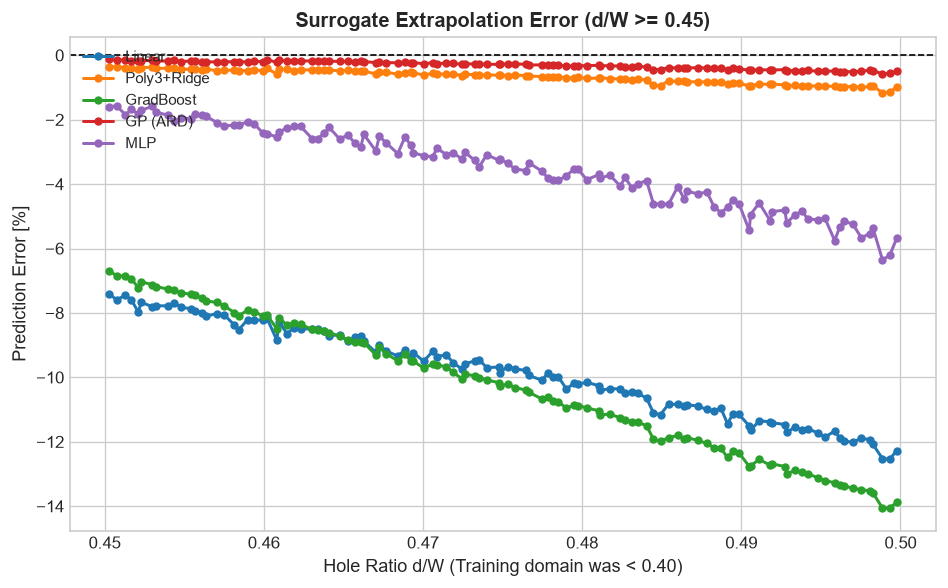

In [10]:
def plot_extrapolation_diagnostics(te_, preds_extrap):
    """Plots prediction error percentage vs hole ratio d/W outside training domain."""
    fig, ax = plt.subplots(figsize=(8, 5))
    y_true_ext = te_["kt_gross"].values
    order = np.argsort(te_["d_over_W"].values)
    d_sorted = te_["d_over_W"].values[order]

    for name, p in preds_extrap.items():
        rel_err = 100 * (p - y_true_ext) / y_true_ext
        ax.plot(d_sorted, rel_err[order], marker="o", markersize=4, lw=1.8, label=name)

    ax.axhline(0, color="black", lw=1, ls="--")
    ax.set_xlabel("Hole Ratio d/W (Training domain was < 0.40)", fontsize=11)
    ax.set_ylabel("Prediction Error [%]", fontsize=11)
    ax.set_title("Surrogate Extrapolation Error (d/W >= 0.45)", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left")
    plt.tight_layout()
    plt.show()

plot_extrapolation_diagnostics(te_, preds_extrap)


### Physics Check: Gaussian Process ARD Length Scales
Automatic Relevance Determination (ARD) fits a separate length scale $\ell_i$ for each input:
* A **small** length scale $\ell_i$ means the output changes rapidly with feature $i$ (high importance).
* A **large** length scale $\ell_i$ means the kernel is nearly flat with respect to feature $i$ (feature does not matter).

In linear elasticity, stress concentration $K_t$ depends purely on the dimensionless shape ($d/W, H/W$), **not on absolute scale ($W$)**.


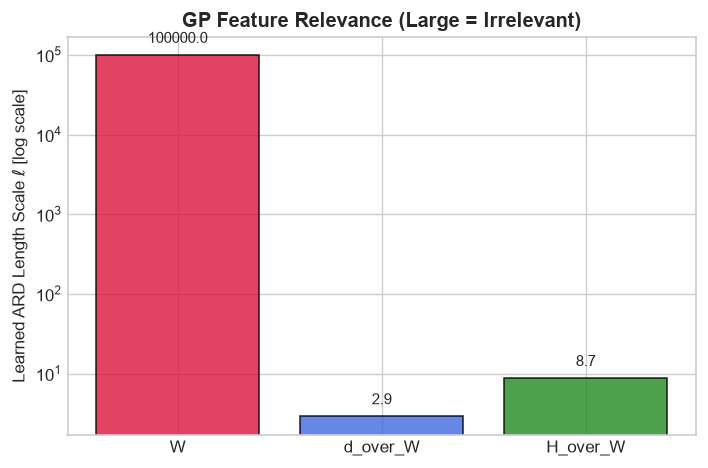

Learned ARD Length Scales:
  W           : 100000.00
  d_over_W    : 2.90
  H_over_W    : 8.75
\nObservation: Plate width W reaches the upper parameter bound (~100,000),
confirming the model learned scale-invariance from data without human priors!


In [11]:
def inspect_gp_relevance(gp_pipeline, feats):
    """Extracts and plots GP ARD learned length scales."""
    gp = gp_pipeline.named_steps["gaussianprocessregressor"]
    length_scales = np.atleast_1d(gp.kernel_.k1.k2.length_scale)

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(feats, length_scales, color=["crimson", "royalblue", "forestgreen"], edgecolor="black", alpha=0.8)
    ax.set_yscale("log")
    ax.set_ylabel("Learned ARD Length Scale $\\ell$ [log scale]")
    ax.set_title("GP Feature Relevance (Large = Irrelevant)", fontweight="bold")

    for bar, val in zip(bars, length_scales):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.3, f"{val:.1f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

    print("Learned ARD Length Scales:")
    for f, l in zip(feats, length_scales):
        print(f"  {f:12s}: {l:.2f}")
    print("\\nObservation: Plate width W reaches the upper parameter bound (~100,000),")
    print("confirming the model learned scale-invariance from data without human priors!")

inspect_gp_relevance(trained_models["GP (ARD)"], FEATS)


## 6. Speedup vs. FEA

Comparing average FEA computation time against surrogate batch prediction latency:


In [12]:
fea_avg_time = (df["t_mesh"] + df["t_solve"]).mean()
gp_latency_s = res_df.loc[res_df["model"] == "GP (ARD)", "predict_us"].iloc[0] * 1e-6
speedup = fea_avg_time / gp_latency_s

print(f"Average FEA time per geometry: {fea_avg_time:.3f} seconds ({fea_avg_time*1000:.1f} ms)")
print(f"GP Surrogate inference time:   {gp_latency_s*1e6:.1f} microseconds ({gp_latency_s*1000:.4f} ms)")
print(f"\\nInference Speedup:             ~{speedup:,.0f}x faster than FEA!")


Average FEA time per geometry: 0.175 seconds (175.0 ms)
GP Surrogate inference time:   24.8 microseconds (0.0248 ms)
\nInference Speedup:             ~7,051x faster than FEA!
